### Project Medical Insurance Cost Prediction

#### I built a regression model to predict medical insurance charges from 6 features — age, sex, BMI, children, smoker status, and region — using the classic 1,338-row insurance dataset. I followed a full ML workflow: EDA, leak-proof preprocessing with pipelines, baseline model, CV-based model comparison across 6 algorithms, hyperparameter tuning with GridSearchCV, and a log-transform on the target to handle skew. My final tuned Random Forest achieves R² ≈ 0.90 and MAE ≈ 1,962 on a held-out test set.


### Dataset: insurance.csv

#### Process:EDA -> preprocessing -> baseline model -> model selection (CV) -> tuning(GridSearchCV) -> final evaluation -> inference

### 1. Importing the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

from sklearn.metrics import(
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
#configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid')

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

RANDOM_STATE = 42
TARGET_COL = "charges" #target column name

### 2. Load Data

In [3]:
df = pd.read_csv("/Users/apple/Documents/python_learning/insurance.csv")

In [4]:
print("DataFrame shape:", df.shape)

DataFrame shape: (1338, 7)


In [5]:
# printing the first 5 rows of dataframe
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


In [6]:
# printing the last 5 rows of the dataframe
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.970,3,no,northwest,10600.548
1334,18,female,31.920,0,no,northeast,2205.981
1335,18,female,36.850,0,no,southeast,1629.833
1336,21,female,25.800,0,no,southwest,2007.945
1337,61,female,29.070,0,yes,northwest,29141.360


### 3.Exploratory Data Analysis (EDA)

In [7]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

**Column Details:**

| Column    | Description                                                | Feature Type                   |
|-----------|------------------------------------------------------------|--------------------------------|
| age       | Age of the individual                                      | Numerical (continuous)         |
| sex       | Gender of the individual (male or female)                  | Categorical                    |
| bmi       | Body Mass Index, a measure of body fat based on weight and height | Numerical (continuous)  |
| children  | Number of dependent children covered by the insurance plan | Numerical (discrete)           |
| smoker    | Whether the individual is a smoker (yes or no)             | Categorical (binary)           |
| region    | Residential region in the US (northeast, northwest, southeast, southwest) | Categorical |
| charges   | Medical insurance cost billed to the individual            | Numerical (continuous, target) |


In [8]:
# basic dataset overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(include=["object"]).columns.to_list()

print("Target column:", TARGET_COL)
print("\nNumerical columns:", num_cols)
print("\nCategorical columns:", cat_cols)

Target column: charges

Numerical columns: ['age', 'bmi', 'children', 'charges']

Categorical columns: ['sex', 'smoker', 'region']


/var/folders/5t/llgr4w914yq0xwwfmwvgz9lm0000gn/T/ipykernel_14232/570544702.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.to_list()


In [10]:
# missing value analysis:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [11]:
# check presence of encoded missing values:
for col in df.columns:
    print(df[col].value_counts().head(20))

age
18    69
19    68
46    29
52    29
48    29
20    29
45    29
47    29
51    29
50    29
28    28
25    28
23    28
27    28
22    28
26    28
24    28
21    28
53    28
54    28
Name: count, dtype: int64
sex
male      676
female    662
Name: count, dtype: int64
bmi
32.300    13
28.310     9
28.880     8
34.100     8
30.800     8
30.875     8
31.350     8
30.495     8
32.775     7
35.200     7
27.360     7
34.800     7
25.460     7
32.110     7
30.590     7
38.060     7
24.320     7
27.645     7
33.330     7
25.800     7
Name: count, dtype: int64
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64
smoker
no     1064
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
charges
1639.563     2
16884.924    1
1725.552     1
4449.462     1
21984.471    1
3866.855     1
3756.622     1
8240.590     1
7281.506     1
6406.411     1
28923.137    1
2721.321     1
27808.7

In [12]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# drop duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


In [13]:
# descriptive statistics
df.describe()

,age,bmi,children,charges
count,1337.000,1337.000,1337.000,1337.000
mean,39.222,30.663,1.096,13279.121
std,14.044,6.100,1.206,12110.360
min,18.000,15.960,0.000,1121.874
25%,27.000,26.290,0.000,4746.344
50%,39.000,30.400,1.000,9386.161
75%,51.000,34.700,2.000,16657.717
max,64.000,53.130,5.000,63770.428


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.000,39.222,14.044,18.000,27.000,39.000,51.000,64.000
bmi,1337.000,30.663,6.100,15.960,26.290,30.400,34.700,53.130
children,1337.000,1.096,1.206,0.000,0.000,1.000,2.000,5.000
charges,1337.000,13279.121,12110.360,1121.874,4746.344,9386.161,16657.717,63770.428


### 3.Data Visualization

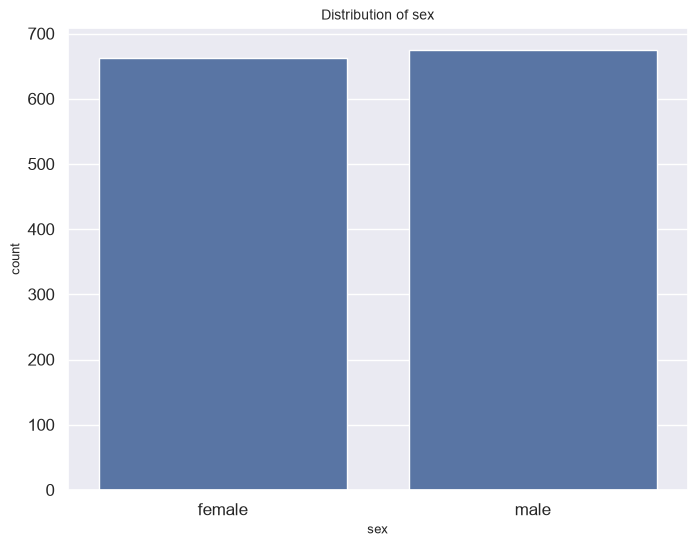

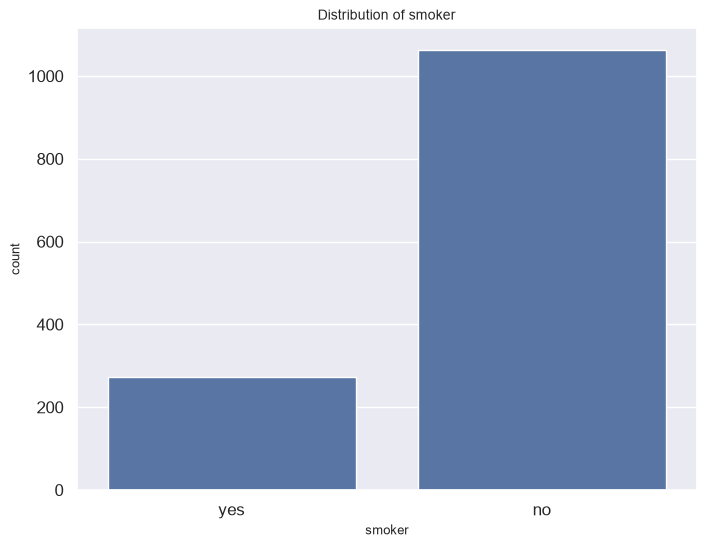

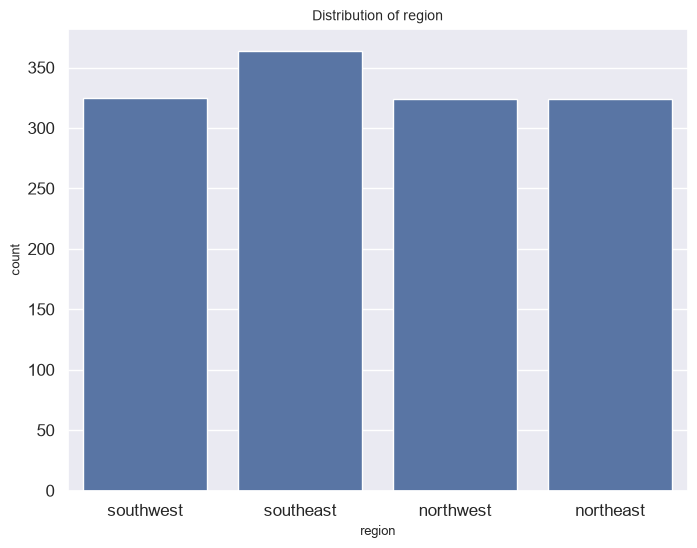

In [15]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.show()

In [16]:
# categorical column analysis
for col in cat_cols:
    print(df[col].value_counts())

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


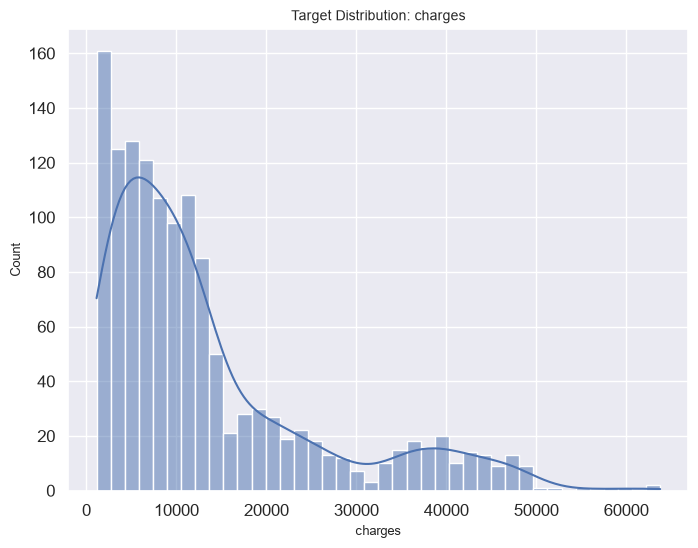

In [17]:
# target column distribution
plt.figure(figsize=(8,6))
sns.histplot(df[TARGET_COL], kde=True, bins=40)
plt.title(f"Target Distribution: {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.show()

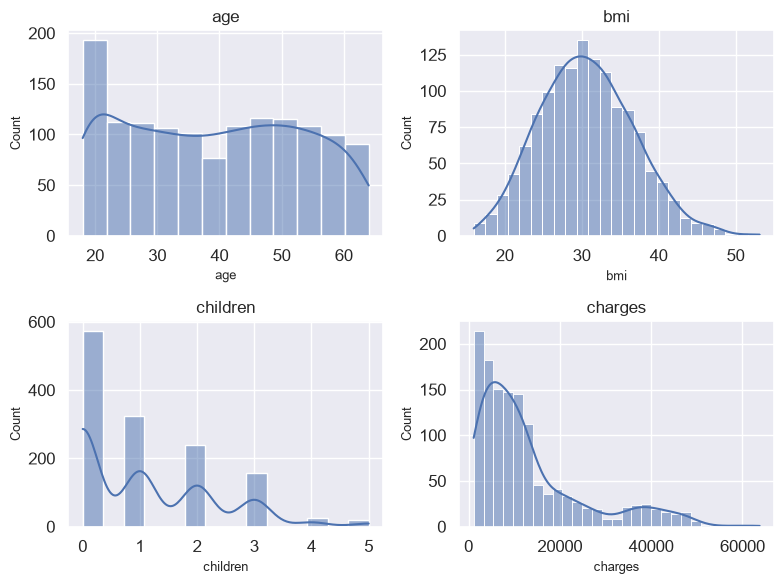

In [18]:
# histogram plot - distribution
fig, axes = plt.subplots(2, 2, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

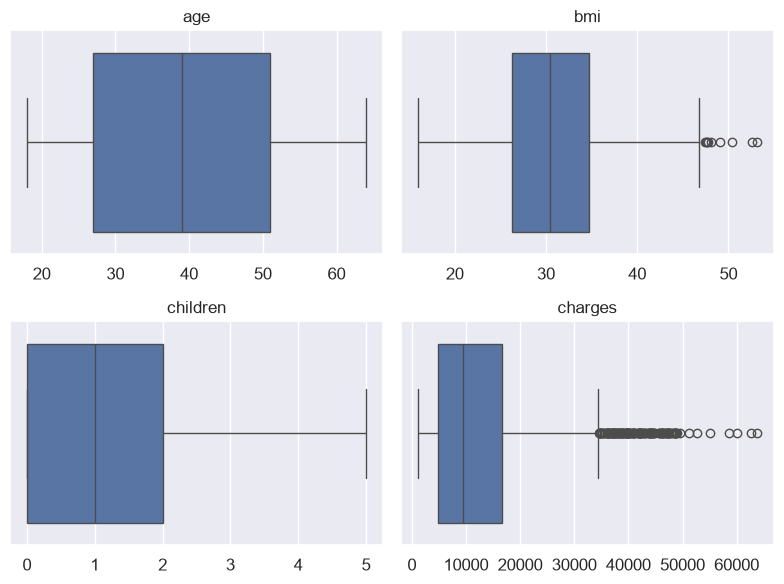

In [19]:
# outliers analysis - boxplot
fig, axes = plt.subplots(2, 2, figsize=(8,6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

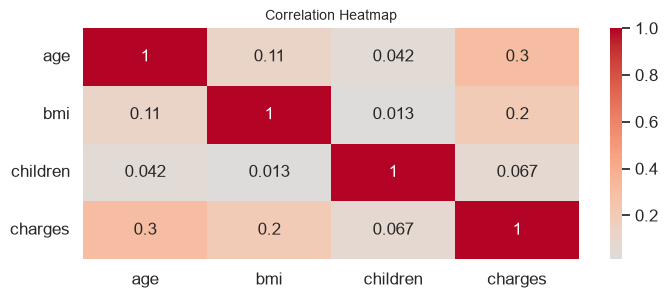

In [20]:
# identify presence of highly correlated columns and feature relationships
plt.figure(figsize=(8,3))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', annot=True, center=0)
plt.title("Correlation Heatmap")
plt.show()

In [21]:
#### Note: We don't have much correlated columns 

In [22]:
# correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("Correlation with target:")
print(corr_with_target)

Correlation with target:
charges    1.000
age        0.298
bmi        0.198
children   0.067
Name: charges, dtype: float64


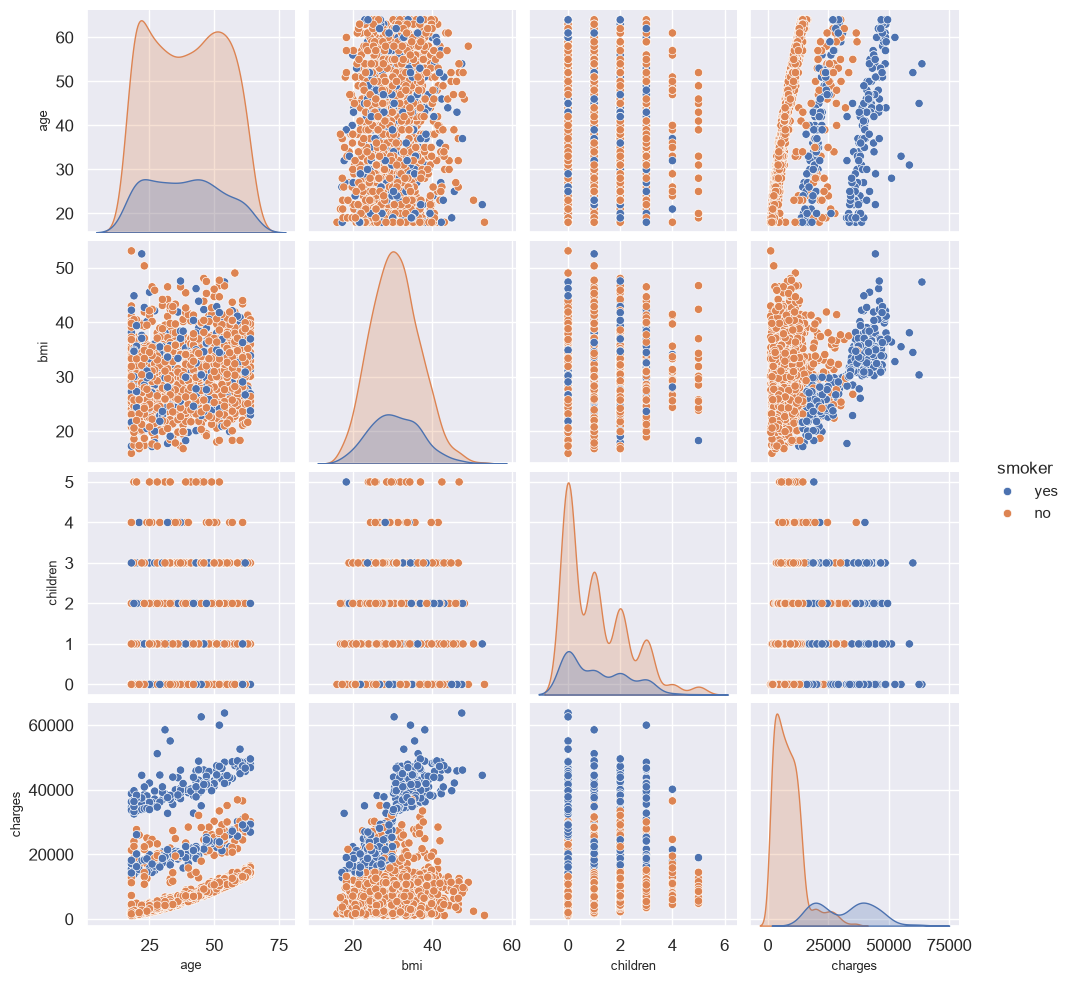

In [23]:
pairplot_cols = num_cols + ["smoker"]

df_pair = df[pairplot_cols].dropna()

sns.pairplot(df_pair, hue="smoker")
plt.show()

### Key Insights from EDA
* Dataset contains a mix of numerical features(age, bmi, children) and categorical features(sex, smoker, region)
* No missing values detected in any columns
* Target variable charges is highly right-skewed with small number of extreme high-cost outliers
* Smoker status shows a very strong seperation in the charges distribution.
* Age & BMI show moderate positive correlation with charges
* No severe multicolinearity among numerical features
* Outliers are prominent in charges (and to lesser extent BMI), especially for smokers


### Preprocessing & Evaluation Plan
* No missing value imputation required
* One-hot encoding for categorical variables(sex, smoker, region)
* Feature scaling applied for linear and regularized models
* No agressive outlier removal, to preserve real-world high-cost medical cases
* Use pipeline and ColumnTransformer to prevent data leakage
* Baseline model using Linear Regression
* Model comparision using cross-validation
* Tree-based models explored to capture non-linear relationships
* Apply log transformation on the target variable (charges) to handle skewness
* Primary evaluation metric: MAE (robust to extreme outliers)
* Secondary metrics: RMSE and R² (to understand worst-case errors and variance explained)
* Hyperparameter tuning performed only on top-performing models
* Final evaluation strictly on a held-out test set


### 4. Data Preprocessing

In [24]:
# seperate features and target as X and Y respectively
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [25]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [26]:
y.head()

0   16884.924
1    1725.552
2    4449.462
3   21984.471
4    3866.855
Name: charges, dtype: float64

In [27]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [28]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1069, 6)
Test shape: (268, 6)


#### Preprocessing Pipeline

In [29]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.to_list()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.to_list()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features) 

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
       ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

#preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


Numerical features: ['age', 'bmi', 'children']
Categorical features: ['sex', 'smoker', 'region']


### 5. Baseline Model (No CV, No Tuning)

In [30]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [31]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the ou

#### Evaluation of base model

In [32]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [33]:
train_baseline_pred[:5]

array([ 2326.02453297,  3289.2193497 , 14447.83525029, 16820.71016479,
       10116.72986155])

In [34]:
y_train[:5]

1114    2396.096
968     3279.869
599    33471.972
170    13405.390
275     9715.841
Name: charges, dtype: float64

In [35]:
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"MAE: {train_baseline_mae:.3f}")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"R2: {train_baseline_r2:.3f}")

=== TRAIN BASELINE METRICS (LinearRegression) ===
MAE: 4181.902
RMSE: 6081.107
R2: 0.730


In [36]:
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)
print("=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"MAE: {test_baseline_mae:.3f}")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"R2: {test_baseline_r2:.3f}")

=== TRAIN BASELINE METRICS (LinearRegression) ===
MAE: 4177.046
RMSE: 5956.343
R2: 0.807


### 6. Model Selection & Optimisation

In [37]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor()
}

In [38]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [39]:
scoring = {
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

In [40]:
rows = []

for model_name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, scoring=scoring, cv=cv, n_jobs=1)
    rows.append({
        "model": model_name,
        "cv_mae": -scores["test_mae"].mean(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_r2": scores["test_r2"].mean()
    })
# sort based on lowest mae value
cv_results = pd.DataFrame(rows).sort_values("cv_mae")
print("=== CV Model Comaprision ===")
print(cv_results)

=== CV Model Comaprision ===
              model   cv_mae  cv_rmse  cv_r2
4      RandomForest 2745.405 4896.064  0.821
5           XGBoost 3104.846 5375.649  0.785
3      DecisionTree 3280.075 6738.921  0.662
0  LinearRegression 4221.963 6123.651  0.723
1             Lasso 4221.980 6123.434  0.723
2             Ridge 4226.798 6123.648  0.723


In [41]:
cv_results

,model,cv_mae,cv_rmse,cv_r2
4,RandomForest,2745.405,4896.064,0.821
5,XGBoost,3104.846,5375.649,0.785
3,DecisionTree,3280.075,6738.921,0.662
0,LinearRegression,4221.963,6123.651,0.723
1,Lasso,4221.980,6123.434,0.723
2,Ridge,4226.798,6123.648,0.723


In [42]:
best_row = cv_results.iloc[0]

best_model_name = best_row["model"]
best_mae = best_row["cv_mae"]
print("Best model based on CV MAE")
print(f"Model: {best_model_name}")
print("CV MAE:", best_mae)


Best model based on CV MAE
Model: RandomForest
CV MAE: 2745.405239876248


### Best Model:RandomForestRegressor

### 7. Hyperparameter Tuning

In [43]:
rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE, verbose=1))
    ]
)

In [44]:
# hyperparameter combination
param_grid_rf = {
    "model__n_estimators": [200, 300, 600, 900],
    "model__max_depth": [None, 8, 15, 25],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log", 0.6, 0.8],
    "model__bootstrap": [True]
}

In [45]:
grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


In [46]:
# perform GridSearchCV
grid.fit(X_train, y_train)

[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.2s
[Paral

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... verbose=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True], 'model__max_depth': [None, 8, ...], 'model__max_features': ['sqrt', 'log', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` para

In [47]:
print("=== Tuned RF (CV) ===")
print("Best CV MAE:", -grid.best_score_)
print("Best params:", grid.best_params_)

=== Tuned RF (CV) ===
Best CV MAE: 2542.17585186875
Best params: {'model__bootstrap': True, 'model__max_depth': 8, 'model__max_features': 0.8, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}


### 8. Retraining with best parameters

In [48]:
rf_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.8,
            min_samples_leaf=4,
            min_samples_split=5,
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1)
        )
    ]
)
            

In [49]:
# train best model on training data (can also be done with refit=True in grid search)
rf_best.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    0.1s finished


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the ou

In [50]:
train_final_pred = rf_best.predict(X_train)

train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("=== FINAL MODEL: (Tuned RF) Train Performance ===")
print(f"MAE: {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2: {train_final_r2:.3f}")

=== FINAL MODEL: (Tuned RF) Train Performance ===
MAE: 2005.006
RMSE: 3690.723
R2: 0.901


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished


In [51]:
test_final_pred = rf_best.predict(X_test)

test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("=== FINAL MODEL: (Tuned RF) Test Performance ===")
print(f"MAE: {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2: {test_final_r2:.3f}")

=== FINAL MODEL: (Tuned RF) Test Performance ===
MAE: 2383.168
RMSE: 4279.199
R2: 0.900


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 300 out of 300 | elapsed:    0.0s finished


### Apply Log Transformation on Target 

In [52]:
rf_best_log = TransformedTargetRegressor(
    regressor=Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(
            bootstrap=True,
            max_depth=8,
            max_features=0.6,
            min_samples_leaf=4,
            min_samples_split=10,
            n_estimators=600,
            random_state=RANDOM_STATE,
            n_jobs=-1)
        )
    ]
),
    func=np.log1p,
    inverse_func=np.expm1
)
                         

In [53]:
rf_best_log.fit(X_train, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...m_state=42))])
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying regressor exposes such an attribute when fit... versionadded:: 0.24,int,6
regressor_ regressor_: objectFitted regressor.,Pipeline,Pipeline(step...m_state=42))])
transformer_ transformer_: objectTransformer used in :meth:`fit` and :meth:`predict`.,FunctionTransformer,FunctionTrans...validate=True)
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"


### 9. Final Evaluation

In [54]:
train_final_pred = rf_best_log.predict(X_train)

train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("=== FINAL MODEL (Tuned RF) Train Performance ===")
print(f"MAE: {train_final_mae:.3f}")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"R2: {train_final_r2:.3f}")

=== FINAL MODEL (Tuned RF) Train Performance ===
MAE: 1746.786
RMSE: 4067.264
R2: 0.879


In [55]:
test_final_pred = rf_best_log.predict(X_test)

test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("=== FINAL MODEL: (Tuned RF) Test Performance ===")
print(f"MAE: {test_final_mae:.3f}")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"R2: {test_final_r2:.3f}")

=== FINAL MODEL: (Tuned RF) Test Performance ===
MAE: 1961.709
RMSE: 4284.714
R2: 0.900
